# Trotterización

En esta breve sesión veremos todo sobre Trotterización necesario para el Hackathon desde 0. Cualquier duda, buscar a Benjamín Sánchez Hernández

## Evolución temporal de Hamiltonianos

Seguramente estas familiarizado con los estados cuánticos. Ahora, imagina que tu dejas un estado evolucionar con el tiempo, es decir, colocas el estado en algún **sistema físico dinámico** y quieres ver como, despues de un tiempo $t$ se ve afectado el estado. 

La ecuación que nos describe la evolución temporal de los estados cuánticos es la ecuación de Schrödinger, la cual, en unidades naturales (suponemos constante de planck igual a 1) es:

$$ -i\frac{d}{dt}|\psi (t)\rangle=H|\psi(t)\rangle$$

donde $H$ es el Hamiltoniano, el cual representa al sistema físico dinámico con el cual vamos a trabajar

Cuando resolvemos dicha ecuación, recuperamos que, para un estado inicial $ |\psi(0)\rangle $, la evolución temporal de dicho estado para un tiempo $t$ esta dado por:

$$|\psi(t)\rangle = e^{-iHt} |\psi(0)\rangle$$

Entonces, es muy sencillo ¿no?, solamente sobre el estado inicial de tu sistema, le aplicas utilizando una computadora cuántica la compuerta que aplique $e^{-iHt}$ al sistema, y listo, recuperas el sistema evolucionado. Facil, ¿no?... Mas o menos. Vamos a dar unos recordatorios sencillos.



### Recordatorio breve: Matrices de rotación

Probablemente al ver la ecuación anterior te preguntaste ¿Como podemos aplicar una rotación sobre un sistema? La respuesta es sorprendentemente simple. Basicamente cualquie libreria que simule o trabaje con computación cuántica (lo veremos en qiskit y pennylane) tiene de opción aplicar las **Matrices de rotación**, que basicamente son operadores que aplican una rotación sobre X,Y y Z al sistema en la esfera de Bloch, y se visualizan como una exponencial con una matriz de Paulli. Aquí coloco sus expresiones para que las recuerdes cuando las necesites

#### Rotación en X

$$
R_x(\theta)
=
e^{-i\frac{\theta}{2}X}
$$

$$
R_x(\theta)
=
\begin{pmatrix}
\cos\left(\frac{\theta}{2}\right)
&
-i\sin\left(\frac{\theta}{2}\right)
\\[6pt]
-i\sin\left(\frac{\theta}{2}\right)
&
\cos\left(\frac{\theta}{2}\right)
\end{pmatrix}
$$


#### Rotación en Y

$$
R_y(\theta)
=
e^{-i\frac{\theta}{2}Y}
$$

$$
R_y(\theta)
=
\begin{pmatrix}
\cos\left(\frac{\theta}{2}\right)
&
-\sin\left(\frac{\theta}{2}\right)
\\[6pt]
\sin\left(\frac{\theta}{2}\right)
&
\cos\left(\frac{\theta}{2}\right)
\end{pmatrix}
$$


#### Rotación en Z

$$
R_z(\theta)
=
e^{-i\frac{\theta}{2}Z}
$$

$$
R_z(\theta)
=
\begin{pmatrix}
e^{-i\theta/2}
&
0
\\[6pt]
0
&
e^{i\theta/2}
\end{pmatrix}
$$

## Exponenciación de matrices y conmutación

Creo que la definición de exponencial de un número real es muy clara, pero ¿Que pasa con la exponenciación de una matriz? Pues asi como la exponencial real tiene su descomposición de taylor donde $e^x=1+x+\frac{x^2}{2!}+\frac{x^3}{3!}...+$, la exponenciación de matrices sigue exactamente el mismo principio. Si A es una matriz cuadrada, entonces 

$$e^A=1+A+\frac{A^2}{2!}+\frac{A^3}{3!}...+$$

Ahora, esto genera algunas propiedades muy interesantes, y es que utilizando la fórmula anterior, se puede demostrar que muchas de las propiedades de la exponencial de numeros reales, tambien se cumplen para la exponencial de matrices PERO CON UNA CONDICIÓN: Las matrices con las que operes deben conmutar, es decir $AB=BA$, similar a como los numeros reales conmutan. Una forma elegante de resumir esto es definir a $[A,B]=AB-BA$ como el **Conmutador** y decir que se cumplen diversas propiedades solo si las matrices en su interior conmutan

y una de estas propiedades es, incomodamente, la ley de los exponentes.

*Teorema: sean A y B 2 matrices tales que [A,B]=0. Entonces se cumple la siguiente propiedad*

$$e^{A+B}=e^{A}e^{B}$$

Una forma elegante de verlo es imaginar que un Hamiltoniano describe 2 efectos similares: Uno (G) es la atracción gravitatoria en z y el otro (Em) es una repulsión electromagnética en x, por lo cual el Hamiltoniano sería H=G+Em. Podemos interpretarlo entonces que el efecto sobre el sistema, por la ec de schrödinger, esta dado por la aplicación de $e^{-i(G+Em)t} |\psi\rangle$. Ahora, si G y Em no interfieren el uno con el otro, entonces con esto en mente, podriamos imaginar que los sistemas son independientes y que el orden de aplicación no altera el sistema, es decir, ambos conmutan, pues $G*Em=Em*G$ de modo que podemos verlo como la implementación de 2 sistemas de manera separada, uno primero y el otro despues, y por eso se puede separar en $e^{-iGt}e^{-iEm t}|\psi\rangle$

Pero a veces, los sistemas no conmutan, de hecho, normalmente no suelen hacerlo. Y aqui empiezan los problemas, pues toma el hamiltoniano $H=X+Z$. al exponenciarlo, $e^{-i(X+Z)t}$ no se puede separar, pues $[X,Z]=-2iY \neq 0$

## Intuición de Trotter: Hamiltoniano "a cachos"

La solución a la que trotter llegó es muy simple pero hermosa al mismo tiempo. Dijo: ¿Y si en lugar de trabajar el hamiltoniano sobre el t completo, lo dividimos en pedazos muy pequeños? Esto lo que hace es que se pueda "forzar" la separación de las 2 matrices debido a que el error con el cual se trabaje sea lo suficientemente bajo para el sistema.

La idea matemática es la siguiente: Imagina que queremos implementar $e^{-i(A+B)T}$. Primero, dividamos el tiempo en r intervalos, de manera que $\Delta t= \frac{t}{r}$.

Entonces tenemos la siguiente forma de evolución temporal:

$$e^{-i(A+B)t} = (e^{-i(A+B)\Delta t})^r$$

Hasta aquí nada raro, ¿verdad?

Entonces tomemos uno y solo uno de los intervalos de acción, y separemos la evolución de froma aproximada: $e^{-i(A+B)t} \approx e^{-iB\Delta t} e^{-iA\Delta t}$. Y si sustituimos esta aproximación en la ecuación anterior, llegamos a algo muy fuerte:

$e^{-i(A+B)t} \approx (e^{-iB \Delta t} e^{-iA \Delta t})^r $ 

donde $\Delta t=\frac{t}{r}$

y la igualdad se cumple en el limite donde r tiende a infinito

### Error de la trotterización

Cuando nosotros realizamos este proceso, podemos visualizarlo como un efecto de la expansión de Baker-Campbell-Hausdorff. Sin entrar en detalles, podemos decir que dados X y Y, si $e^Xe^Y=e^{(A+B)\Delta t+\frac{1}{2}[A,B]\Delta t^2...}$

El primer termino que nos molesta contiene a $[A,B]\Delta t^2$, y si  $[A,B]\neq 0$, entonces el error global depende justamente de $O(\frac{t^2}{r})$

## Suzuki-Trotter en segundo orden

Existe una mejor aproximación del sistema si usamos

$$e^{-i(A+B)\Delta t} \approx e^{-iA\Delta t/ 2}e^{-iB\Delta t}e^{-iA\Delta t/ 2}$$

cuyo error escala como $O(\frac{t^3}{r^2})$

## Ejemplos intuitivos de Trotterización

### Hamiltoniano $H=\frac{\omega}{2}Z$

Este ejemplo es bonito, pues nos permite ver como evoluciona un Hamiltoniano sencillo sin usar trotterización aun y utilizar las herramientas de Qiskit para visualizarlo de forma sencilla:

Preparemos el estado inicial $|\psi(0)\rangle$ en $|+\rangle$. Veamos como evoluciona este estado con el tiempo:

Ahora, recordando que $R_Z(\theta)=e^{-i\frac{\theta}{2}Z}$, notemos rapidamente que $e^{-iHt}=e^{-i\omega tZ/2}=R_Z(\omega t)$

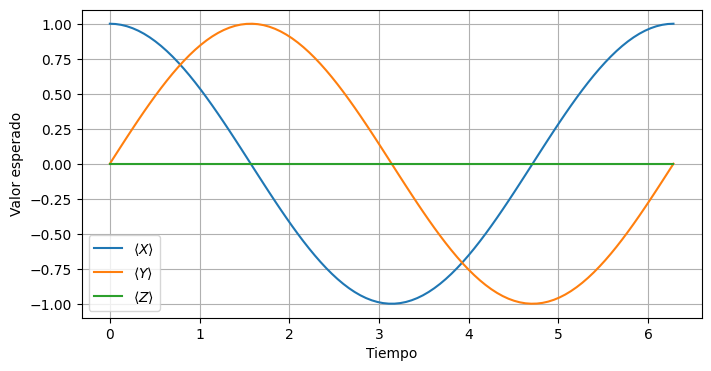

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp


X = SparsePauliOp("X") # Pauli X operator
Y = SparsePauliOp("Y") # Pauli Y operator
Z = SparsePauliOp("Z") # Pauli Z operator


def evolve_with_z(t: float, omega: float = 1.0) -> Statevector:  # Evoluciona |+> bajo H = (omega / 2) Z
    circuit = QuantumCircuit(1) # Creamos un circuito de un qubit

    circuit.h(0) #Lo volvemos a |+> aplicando la puerta Hadamard

    
    circuit.rz(omega * t, 0) # Aplicamos la puerta de rotación alrededor del eje Z con ángulo omega * t

    return Statevector.from_instruction(circuit)


omega = 1.0 # Asignamos un valor a omega
times = np.linspace(0, 2 * np.pi, 100) # Damos el espacio de soluciones

mean_x = [] # Lista para almacenar los valores esperados de X
mean_y = [] # Lista para almacenar los valores esperados de Y
mean_z = [] # Lista para almacenar los valores esperados de Z

for t in times:
    state = evolve_with_z(t, omega)

    mean_x.append(np.real(state.expectation_value(X))) 
    mean_y.append(np.real(state.expectation_value(Y)))
    mean_z.append(np.real(state.expectation_value(Z)))


plt.figure(figsize=(8, 4))
plt.plot(times, mean_x, label=r"$\langle X\rangle$")
plt.plot(times, mean_y, label=r"$\langle Y\rangle$")
plt.plot(times, mean_z, label=r"$\langle Z\rangle$")
plt.xlabel("Tiempo")
plt.ylabel("Valor esperado")
plt.legend()
plt.grid()
plt.show()

# Ejercicio Mariana y Amado: Hamiltoniano con $H=aX+bZ$

Dado el hamiltoniano anterior, expliquen por que este se debe trotterizar, y trotterizalo para el estado inicial que tu desees

### ¿Por qué se debe trotterizar?
Porque $X$ y $Z$ no conmutan.

### Trotterización:

$$
\begin{align*}
e^{-i H t} &= e^{-i(aX + bZ)t}, \\
&= \left(e^{-i(aX + bZ)\Delta t}\right)^r, \\
&= \left(e^{-i(aX\Delta t + bZ\Delta t)}\right)^r, \\
&\approx \left(e^{-iaX\Delta t} e^{-ibZ\Delta t}\right)^r, \\
&= \left(e^{-iaX\Delta t} e^{-ibZ\Delta t}\right)^r, \\
&= \left(e^{-2iaX\Delta t/2} e^{-2ibZ\Delta t/2}\right)^r, \\
&= \left(e^{-2iaX\Delta t/2} e^{-2ibZ\Delta t/2}\right)^r, \\
&= \left[R_X(2a\Delta t) R_Z(2b\Delta t)\right]^r.
\end{align*}
$$

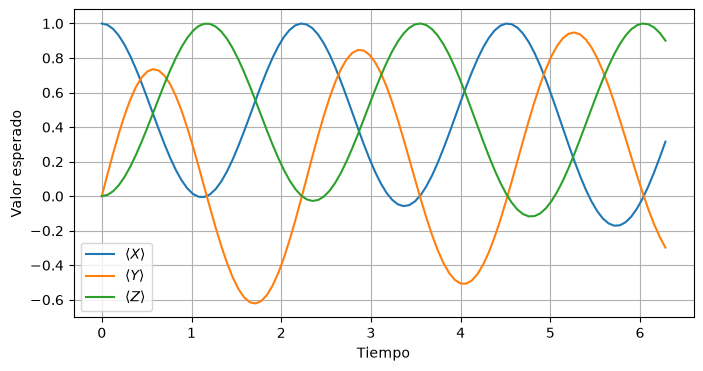

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp


X = SparsePauliOp("X")
Y = SparsePauliOp("Y")
Z = SparsePauliOp("Z")


def trotterized_hamiltonian(circ: QuantumCircuit, dt: float, r:int, a:complex, b:complex) -> None:
    for _ in range(r):
        circ.rx(2*a*dt, 0)
        circ.rz(2*b*dt, 0)

def evolve(t: float, r: int, omega: float = 1.0) -> Statevector:
    dt = t/r
    circuit = QuantumCircuit(1)
    circuit.h(0)
    trotterized_hamiltonian(circuit, dt, r, 1.0, 1.0)
    return Statevector.from_instruction(circuit)


omega = 1.0
times = np.linspace(0, 2 * np.pi, 100)

mean_x = []
mean_y = []
mean_z = []

for t in times:
    state = evolve(t, 10, omega)

    mean_x.append(np.real(state.expectation_value(X))) 
    mean_y.append(np.real(state.expectation_value(Y)))
    mean_z.append(np.real(state.expectation_value(Z)))


plt.figure(figsize=(8, 4))
plt.plot(times, mean_x, label=r"$\langle X\rangle$")
plt.plot(times, mean_y, label=r"$\langle Y\rangle$")
plt.plot(times, mean_z, label=r"$\langle Z\rangle$")
plt.xlabel("Tiempo")
plt.ylabel("Valor esperado")
plt.legend()
plt.grid()
plt.show()

### Segundo orden????

$$
\begin{align*}
\left(e^{-i(aX+bZ)\Delta t}\right)^r &\approx \left(e^{-iaX\Delta t/2}e^{-ibZ\Delta t}e^{-iaX\Delta t/2}\right)^r, \\
&= \left(e^{-iaX\Delta t/2}e^{-i2bZ\Delta t/2}e^{-iaX\Delta t/2}\right)^r, \\
&= \left[R_X(a\Delta t)R_Z(2b\Delta t)R_X(a\Delta t)\right]^r, \\
\end{align*}
$$

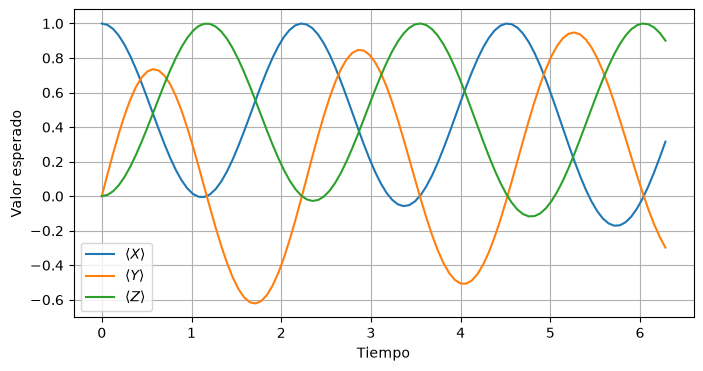

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp


X = SparsePauliOp("X")
Y = SparsePauliOp("Y")
Z = SparsePauliOp("Z")


def trotterized_hamiltonian2(circ: QuantumCircuit, dt: float, r:int, a:complex, b:complex) -> None:
    for _ in range(r):
        circ.rx(a*dt, 0)
        circ.rz(2*b*dt, 0)
        circ.rx(a*dt, 0)

def evolve(t: float, r: int, omega: float = 1.0) -> Statevector:
    dt = t/r
    circuit = QuantumCircuit(1)
    circuit.h(0)
    trotterized_hamiltonian(circuit, dt, r, 1.0, 1.0)
    return Statevector.from_instruction(circuit)


omega = 1.0
times = np.linspace(0, 2 * np.pi, 100)

mean_x = []
mean_y = []
mean_z = []

for t in times:
    state = evolve(t, 10, omega)

    mean_x.append(np.real(state.expectation_value(X))) 
    mean_y.append(np.real(state.expectation_value(Y)))
    mean_z.append(np.real(state.expectation_value(Z)))


plt.figure(figsize=(8, 4))
plt.plot(times, mean_x, label=r"$\langle X\rangle$")
plt.plot(times, mean_y, label=r"$\langle Y\rangle$")
plt.plot(times, mean_z, label=r"$\langle Z\rangle$")
plt.xlabel("Tiempo")
plt.ylabel("Valor esperado")
plt.legend()
plt.grid()
plt.show()